# CRICKBUZZ ANALYSIS

### 1. Import Libraries and Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import re

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 60)

raw = pd.read_csv('Cricket_data.csv')
print('raw shape: ', raw.shape)
raw.head(3)

raw shape:  (202, 48)


,matchID,seriesID,seriesName,matchDescription,matchFormat,startDate,endDate,state,status,teamID,teamName,team1Name,team1imageID,team2teamId,team2Name,team2Name.1,team2imageId,venueInfoid,venueInfoground,city,timezone,latitude,longitude,currBatTeamId,seriesStartDt,seriesEndDt,isTimeAnnounced,stateTitle,inngs1inningsId,inngs1runs,inngs1wickets,inngs1overs,inngs2inningsId,inngs2runs,inngs2wickets,inngs2overs,inngs1inningsId.1,inngs1runs.1,inngs1wickets.1,inngs1overs.1,inningsId,inngs2runs.1,inngs2wickets.1,inngs2overs.1,inngs2isDeclared,inngs1isDeclared,inngs2isFollowOn,inngs1isDeclared.1
0,78635.0,6927.0,"England tour of India, 2024",2nd Test,TEST,1706846400000,1707217200000,Complete,India won by 106 runs,2.0,India,IND,172115.0,9.0,England,ENG,172123.0,154.0,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,+05:30,17.797459,83.352254,2.0,1706140800000,1710288000000,True,IND Won,1.0,396.0,10.0,111.6,3.0,255.0,10.0,78.3,2.0,253.0,10.0,55.5,4.0,292.0,10.0,69.2,NaN,NaN,NaN,NaN
1,78082.0,6892.0,"South Africa tour of New Zealand, 2024",2nd Test,TEST,1707775200000,1708146000000,Complete,New Zealand won by 7 wkts,11.0,South Africa,RSA,172126.0,13.0,New Zealand,NZ,172128.0,100.0,Seddon Park,Hamilton,+13:00,-37.786654,175.266647,13.0,1706486400000,1708300800000,True,NZ Won,1.0,242.0,10.0,97.2,3.0,235.0,10.0,69.5,2.0,211.0,10.0,77.3,4.0,269.0,3.0,94.2,NaN,NaN,NaN,NaN
2,78075.0,6892.0,"South Africa tour of New Zealand, 2024",1st Test,TEST,1706997600000,1707368400000,Complete,New Zealand won by 281 runs,13.0,New Zealand,NZ,172128.0,11.0,South Africa,RSA,172126.0,393.0,Bay Oval,Mount Maunganui,+13:00,-37.670300,176.212006,13.0,1706486400000,1708300800000,True,NZ Won,1.0,511.0,10.0,143.6,3.0,179.0,4.0,42.6,2.0,162.0,10.0,72.5,4.0,247.0,10.0,79.6,True,NaN,NaN,NaN


In [2]:
# Raw Rename Columns
df = raw.rename(columns={
    'matchID':'match_id','seriesID':'series_id','seriesName':'series_name',
    'matchDescription':'match_desc','matchFormat':'match_format',
    'startDate':'start_ms','endDate':'end_ms','status':'status',
    'teamID':'team1_id','teamName':'team1_name','team1Name':'team1_code','team1imageID':'team1_img',
    'team2teamId':'team2_id','team2Name':'team2_name','team2Name.1':'team2_code','team2imageId':'team2_img',
    'venueInfoid':'venue_id','venueInfoground':'venue','city':'city','timezone':'timezone',
    'latitude':'lat','longitude':'lon','seriesStartDt':'series_start_ms','seriesEndDt':'series_end_ms',
    'stateTitle':'state_title',
    'inngs1runs':'inn1_runs','inngs1wickets':'inn1_wkts','inngs1overs':'inn1_overs',
    'inngs1runs.1':'inn2_runs','inngs1wickets.1':'inn2_wkts','inngs1overs.1':'inn2_overs',
    'inngs2runs':'inn3_runs','inngs2wickets':'inn3_wkts','inngs2overs':'inn3_overs',
    'inngs2runs.1':'inn4_runs','inngs2wickets.1':'inn4_wkts','inngs2overs.1':'inn4_overs',
})

keep = ['match_id','series_id','series_name','match_desc','match_format','start_ms','end_ms',
        'status','state_title','team1_id','team1_name','team1_code','team2_id','team2_name',
        'team2_code','venue_id','venue','city','timezone','lat','lon',
        'series_start_ms','series_end_ms',
        'inn1_runs','inn1_wkts','inn1_overs','inn2_runs','inn2_wkts','inn2_overs',
        'inn3_runs','inn3_wkts','inn3_overs','inn4_runs','inn4_wkts','inn4_overs']
df = df[keep]
print('Kept', df.shape[1], 'clean columns')
df.head(3)

Kept 35 clean columns


,match_id,series_id,series_name,match_desc,match_format,start_ms,end_ms,status,state_title,team1_id,team1_name,team1_code,team2_id,team2_name,team2_code,venue_id,venue,city,timezone,lat,lon,series_start_ms,series_end_ms,inn1_runs,inn1_wkts,inn1_overs,inn2_runs,inn2_wkts,inn2_overs,inn3_runs,inn3_wkts,inn3_overs,inn4_runs,inn4_wkts,inn4_overs
0,78635.0,6927.0,"England tour of India, 2024",2nd Test,TEST,1706846400000,1707217200000,India won by 106 runs,IND Won,2.0,India,IND,9.0,England,ENG,154.0,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,+05:30,17.797459,83.352254,1706140800000,1710288000000,396.0,10.0,111.6,253.0,10.0,55.5,255.0,10.0,78.3,292.0,10.0,69.2
1,78082.0,6892.0,"South Africa tour of New Zealand, 2024",2nd Test,TEST,1707775200000,1708146000000,New Zealand won by 7 wkts,NZ Won,11.0,South Africa,RSA,13.0,New Zealand,NZ,100.0,Seddon Park,Hamilton,+13:00,-37.786654,175.266647,1706486400000,1708300800000,242.0,10.0,97.2,211.0,10.0,77.3,235.0,10.0,69.5,269.0,3.0,94.2
2,78075.0,6892.0,"South Africa tour of New Zealand, 2024",1st Test,TEST,1706997600000,1707368400000,New Zealand won by 281 runs,NZ Won,13.0,New Zealand,NZ,11.0,South Africa,RSA,393.0,Bay Oval,Mount Maunganui,+13:00,-37.670300,176.212006,1706486400000,1708300800000,511.0,10.0,143.6,162.0,10.0,72.5,179.0,4.0,42.6,247.0,10.0,79.6


## 2. Fix Data type: IDs from flaot to integer

In [3]:
for col in ['match_id','series_id','team1_id','team2_id','venue_id']:
    df[col] = df[col].astype('Int64')   
df[['match_id','series_id','team1_id','team2_id','venue_id']].dtypes

match_id     Int64
series_id    Int64
team1_id     Int64
team2_id     Int64
venue_id     Int64
dtype: object

In [4]:
# Convert the 'Date' column to datetime format

for src, dst in [('start_ms','start_date'),('end_ms','end_date'),
                 ('series_start_ms','series_start'),('series_end_ms','series_end')]:
    df[dst] = pd.to_datetime(df[src], unit='ms').dt.normalize()
df = df.drop(columns=['start_ms','end_ms','series_start_ms','series_end_ms'])
df[['start_date','end_date','series_start','series_end']].head()

,start_date,end_date,series_start,series_end
0,2024-02-02,2024-02-06,2024-01-25,2024-03-13
1,2024-02-12,2024-02-17,2024-01-29,2024-02-19
2,2024-02-03,2024-02-08,2024-01-29,2024-02-19
3,2024-02-17,2024-02-17,2024-02-02,2024-02-23
4,2024-02-14,2024-02-14,2024-02-02,2024-02-23


## 3. Innings Cleanup

In [5]:
# Function to convert overs into decimal format
def convert_overs(overs):

    # If value is missing
    if pd.isna(overs):
        return np.nan

    # Whole overs part
    overs_completed = int(overs)

    # Balls part (e.g. 49.3 → 3 balls)
    balls = round((overs - overs_completed) * 10)

    # Convert balls into fraction of an over
    return overs_completed + (balls / 6)

# Apply for all 4 innings
for inning in [1, 2, 3, 4]:

    # Convert runs and wickets to integer
    df[f'inn{inning}_runs'] = df[f'inn{inning}_runs'].astype('Int64')
    df[f'inn{inning}_wkts'] = df[f'inn{inning}_wkts'].astype('Int64')

    # Create new decimal overs column
    df[f'inn{inning}_overs_dec'] = (
        df[f'inn{inning}_overs']
        .apply(convert_overs)
        .round(3)
    )

# Check result
df[['inn1_overs', 'inn1_overs_dec']].head()

,inn1_overs,inn1_overs_dec
0,111.6,112.000
1,97.2,97.333
2,143.6,144.000
3,18.6,19.000
4,48.2,48.333


## 4. Add Helper columns

~ Extract the winners, margin and result type out of the text and add *Year*,*month*,*gender*, run rates and total runs.

In [6]:
# Year and month column Added
df['year'] = df['start_date'].dt.year
df['month'] = df['start_date'].dt.month

# Add gender
df['gender'] = np.where(
    df['team1_name'].str.contains('Women',na=False) |
    df['series_name'].str.contains('Women',na=False),'Women','Men')

# Winner code and name
df['winner_code'] = df['state_title'].str.replace(' Won', '', regex=False).str.strip()
code2name = {}
for _, r in df.iterrows():
    code2name[r['team1_code']] = r['team1_name']
    code2name[r['team2_code']] = r['team2_name']
df['winner_name'] = df['winner_code'].map(code2name)

# Win Type
df['win_type'] = np.select(
    [df['status'].str.contains('runs', case=False, na=False),
        df['status'].str.contains('wkt|wicket', case=False, na=False),
        df['status'].str.contains('innings', case=False, na=False),
        df['status'].str.contains('draw', case=False, na=False),
        df['status'].str.contains('tie', case=False, na=False)],
    ['Runs','Wickets','Innings','Draw','Tie'],
    default='Other')

# Win Margin
df['win_margin'] = (df['status'].str.extract(r'(\d+)').astype('Int64'))

# Helper Function for cricket overs
def overs_to_decimal(over):
    if pd.isna(over):
        return np.nan
    
    over = float(over)
    whole_overs = int(over)
    balls = round((over - whole_overs) * 10)
    return whole_overs + (balls / 6)

# Innings 1 Run Rate
df['inn1_run_rate'] = (df['inn1_runs'] / df['inn1_overs'].apply(overs_to_decimal)).round(2)

# Innings 2 Run Rate
df['inn2_run_rate'] = (df['inn2_runs'] / df['inn2_overs'].apply(overs_to_decimal)).round(2)

# First Innings Score
df['first_inns_score'] = df['inn1_runs']

# Second Innings Score
df['second_inns_score'] = df['inn2_runs']

# Total Match Runs
df['total_match_runs']  = df[['inn1_runs','inn2_runs','inn3_runs','inn4_runs']].sum(axis=1).astype('Int64')

df[['match_format','team1_name','team2_name','winner_name','win_type','inn1_run_rate','inn2_run_rate',
    'win_margin','first_inns_score','second_inns_score','total_match_runs','gender','year','month']].head(8)


,match_format,team1_name,team2_name,winner_name,win_type,inn1_run_rate,inn2_run_rate,win_margin,first_inns_score,second_inns_score,total_match_runs,gender,year,month
0,TEST,India,England,India,Runs,3.54,4.53,106,396,253,1196,Men,2024,2
1,TEST,South Africa,New Zealand,New Zealand,Wickets,2.49,2.72,7,242,211,957,Men,2024,2
2,TEST,New Zealand,South Africa,New Zealand,Runs,3.55,2.22,281,511,162,1099,Men,2024,2
3,T20,Sri Lanka,Afghanistan,Sri Lanka,Runs,8.42,7.8,4,160,156,316,Men,2024,2
4,ODI,Afghanistan,Sri Lanka,Sri Lanka,Wickets,5.5,7.56,7,266,267,533,Men,2024,2
5,ODI,Sri Lanka,Afghanistan,Sri Lanka,Runs,6.16,4.52,155,308,153,461,Men,2024,2
6,ODI,Sri Lanka,Afghanistan,Sri Lanka,Runs,7.62,6.78,42,381,339,720,Men,2024,2
7,TEST,Afghanistan,Sri Lanka,Sri Lanka,Wickets,3.16,4.02,10,198,439,989,Men,2024,2


### 5. Validate the Cleaned data

In [7]:
print('Final shape:', df.shape)
nulls = df.isna().sum()
print('\nRemaining nulls (all expected):')
print(nulls[nulls > 0].to_string())
print('\nResult types:', df['win_type'].value_counts().to_dict())

Final shape: (202, 51)

Remaining nulls (all expected):
inn1_wkts              1
inn2_runs              2
inn2_wkts              9
inn2_overs             2
inn3_runs            155
inn3_wkts            156
inn3_overs           155
inn4_runs            162
inn4_wkts            164
inn4_overs           162
inn2_overs_dec         2
inn3_overs_dec       155
inn4_overs_dec       162
winner_name           18
win_margin            16
inn2_run_rate          2
second_inns_score      2

Result types: {'Runs': 103, 'Wickets': 82, 'Draw': 15, 'Other': 2}


### 6. Quick analysis 

In [10]:
# Matches by format and gender
print('Matches by format:')
print(df['match_format'].value_counts(), '\n')

# Average first innings run rate by format
print('Average first innings run rate by format:')
print(df.groupby('match_format')['inn1_run_rate'].mean().round(2), '\n')

# chasing 
chasing = df[df['win_type'].isin(['Runs','Wickets'])]
print('Wins by win type:')
print(chasing['win_type'].value_counts())


Matches by format:
match_format
T20     107
TEST     59
ODI      36
Name: count, dtype: int64 

Average first innings run rate by format:
match_format
ODI     4.93
T20     7.37
TEST    3.21
Name: inn1_run_rate, dtype: Float64 

Wins by win type:
win_type
Runs       103
Wickets     82
Name: count, dtype: int64


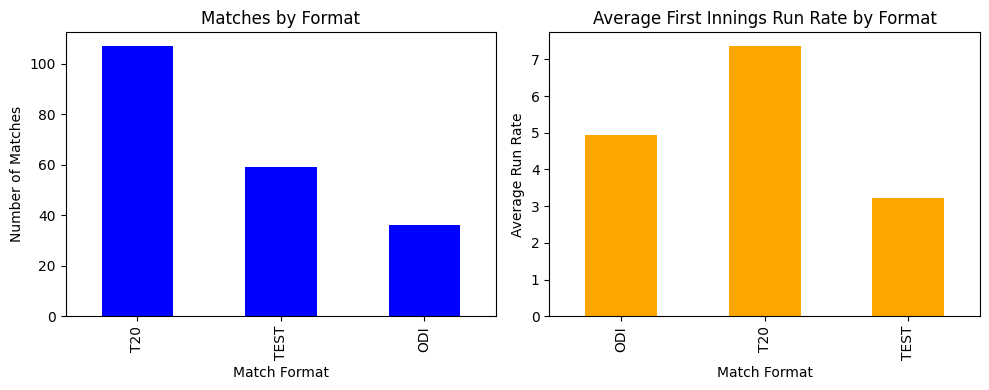

chart saved successfully!


In [11]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

# Chart 1
df['match_format'].value_counts().plot(kind='bar', ax=ax[0], color='blue')
ax[0].set_title('Matches by Format')
ax[0].set_xlabel('Match Format')
ax[0].set_ylabel('Number of Matches')

# Chart 2
df.groupby('match_format')['inn1_run_rate'].mean().plot(kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Average First Innings Run Rate by Format')
ax[1].set_xlabel('Match Format')
ax[1].set_ylabel('Average Run Rate')

plt.tight_layout()
plt.savefig('chart1_matches_by_format_and_run_rate.png')
plt.show()

print('chart saved successfully!')


### 7. Export for the next stages


In [12]:
ordered = ['match_id','series_id','series_name','match_desc','match_format','gender',
           'start_date','end_date','year','month',
           'team1_id','team1_name','team1_code','team2_id','team2_name','team2_code',
           'winner_name','winner_code','win_type','win_margin',
           'venue','city','lat','lon',
           'inn1_runs','inn1_wkts','inn1_overs_dec','inn1_run_rate',
           'inn2_runs','inn2_wkts','inn2_overs_dec','inn2_run_rate',
           'inn3_runs','inn3_wkts','inn3_overs_dec',
           'inn4_runs','inn4_wkts','inn4_overs_dec',
           'first_inns_score','second_inns_score','total_match_runs','status']
clean = df[ordered].copy()
clean.to_csv('Cricket_data_CLEANED.csv', index=False)
print('CSV written:', clean.shape)
clean.head()

CSV written: (202, 42)


,match_id,series_id,series_name,match_desc,match_format,gender,start_date,end_date,year,month,team1_id,team1_name,team1_code,team2_id,team2_name,team2_code,winner_name,winner_code,win_type,win_margin,venue,city,lat,lon,inn1_runs,inn1_wkts,inn1_overs_dec,inn1_run_rate,inn2_runs,inn2_wkts,inn2_overs_dec,inn2_run_rate,inn3_runs,inn3_wkts,inn3_overs_dec,inn4_runs,inn4_wkts,inn4_overs_dec,first_inns_score,second_inns_score,total_match_runs,status
0,78635,6927,"England tour of India, 2024",2nd Test,TEST,Men,2024-02-02,2024-02-06,2024,2,2,India,IND,9,England,ENG,India,IND,Runs,106,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,17.797459,83.352254,396,10,112.000,3.54,253,10,55.833,4.53,255,10,78.500,292,10,69.333,396,253,1196,India won by 106 runs
1,78082,6892,"South Africa tour of New Zealand, 2024",2nd Test,TEST,Men,2024-02-12,2024-02-17,2024,2,11,South Africa,RSA,13,New Zealand,NZ,New Zealand,NZ,Wickets,7,Seddon Park,Hamilton,-37.786654,175.266647,242,10,97.333,2.49,211,10,77.500,2.72,235,10,69.833,269,3,94.333,242,211,957,New Zealand won by 7 wkts
2,78075,6892,"South Africa tour of New Zealand, 2024",1st Test,TEST,Men,2024-02-03,2024-02-08,2024,2,13,New Zealand,NZ,11,South Africa,RSA,New Zealand,NZ,Runs,281,Bay Oval,Mount Maunganui,-37.670300,176.212006,511,10,144.000,3.55,162,10,72.833,2.22,179,4,43.000,247,10,80.000,511,162,1099,New Zealand won by 281 runs
3,87901,7481,"Afghanistan tour of Sri Lanka, 2024",1st T20I,T20,Men,2024-02-17,2024-02-17,2024,2,5,Sri Lanka,SL,96,Afghanistan,AFG,Sri Lanka,SL,Runs,4,Rangiri Dambulla International Stadium,Dambulla,7.859556,80.634026,160,10,19.000,8.42,156,9,20.000,7.8,<NA>,<NA>,NaN,<NA>,<NA>,NaN,160,156,316,Sri Lanka won by 4 runs
4,87897,7481,"Afghanistan tour of Sri Lanka, 2024",3rd ODI,ODI,Men,2024-02-14,2024-02-14,2024,2,96,Afghanistan,AFG,5,Sri Lanka,SL,Sri Lanka,SL,Wickets,7,Pallekele International Cricket Stadium,Pallekele,7.280691,80.722493,266,10,48.333,5.5,267,3,35.333,7.56,<NA>,<NA>,NaN,<NA>,<NA>,NaN,266,267,533,Sri Lanka won by 7 wkts


### 8. A Team-Centric(long) Table

The raw frame has two teams per row. Almost every team question gets easier
once we have **one row per team per match** with a `won` flag

In [23]:
cols = ['match_id','match_format','gender','start_date','venue','city','total_match_runs','winner_name']

left  = df[cols + ['team1_name','team2_name']].rename(
            columns={'team1_name':'team','team2_name':'opponent'})
right = df[cols + ['team2_name','team1_name']].rename(
            columns={'team2_name':'team','team1_name':'opponent'})

team_match = pd.concat([left, right], ignore_index=True)
team_match['won']     = team_match['team'] == team_match['winner_name']
team_match['decided'] = team_match['winner_name'].notna()

print('team_match rows:', len(team_match), '(= 2 x matches)')
team_match.head()

team_match rows: 404 (= 2 x matches)


,match_id,match_format,gender,start_date,venue,city,total_match_runs,winner_name,team,opponent,won,decided
0,78635,TEST,Men,2024-02-02,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,1196,India,India,England,True,True
1,78082,TEST,Men,2024-02-12,Seddon Park,Hamilton,957,New Zealand,South Africa,New Zealand,False,True
2,78075,TEST,Men,2024-02-03,Bay Oval,Mount Maunganui,1099,New Zealand,New Zealand,South Africa,True,True
3,87901,T20,Men,2024-02-17,Rangiri Dambulla International Stadium,Dambulla,316,Sri Lanka,Sri Lanka,Afghanistan,True,True
4,87897,ODI,Men,2024-02-14,Pallekele International Cricket Stadium,Pallekele,533,Sri Lanka,Afghanistan,Sri Lanka,False,True


### 9. Team win-rate leaderboard (win % over decided games)

In [19]:
stats = (team_match.groupby('team')
         .agg(played=('match_id','count'),
              wins=('won','sum'),
              decided=('decided','sum'))
         .query('played >= 4'))
stats['win_pct'] = (100 * stats['wins'] / stats['decided'].replace(0, np.nan)).round(1)
leaderboard = stats.sort_values(['win_pct','wins'], ascending=False)
leaderboard.head(15)

,played,wins,decided,win_pct
team,,,,
Saudi Arabia,7,7,7,100.0
United Arab Emirates Women,6,6,6,100.0
Hong Kong,5,5,5,100.0
Rangpur Riders,5,5,5,100.0
Sri Lanka,5,5,5,100.0
Comilla Victorians,4,4,4,100.0
Otago,4,4,4,100.0
Canterbury,4,3,3,100.0
Malaysia Women,9,8,9,88.9


## 10. Bat-first vs chase
First the headline split by format, then quartile the first-innings score and
see how often batting first actually won in each band (limited-overs only).

In [20]:
limited_overs = df[df['match_format'].isin(['T20','ODI'])].copy()
split = (limited_overs[limited_overs['win_type'].isin(['Runs','Wickets'])]
         .groupby(['match_format','win_type']).size()
         .unstack(fill_value=0))
split['bat_first_win_pct'] = (100*split['Runs']/(split['Runs']+split['Wickets'])).round(1)
print(split)

win_type      Runs  Wickets  bat_first_win_pct
match_format                                  
ODI             16       19               45.7
T20             59       48               55.1


In [21]:
band = limited_overs[limited_overs['win_type'].isin(['Runs','Wickets']) & limited_overs['first_inns_score'].notna()].copy()
band['score_q'] = pd.qcut(band['first_inns_score'], 4, labels=['Q1 low','Q2','Q3','Q4 high'])
defend = band.groupby('score_q', observed=True).apply(
    lambda g: pd.Series({
        'games': len(g),
        'min_score': int(g['first_inns_score'].min()),
        'max_score': int(g['first_inns_score'].max()),
        'bat_first_win_pct': round(100*(g['win_type']=='Runs').mean(),1)}))
print(defend)

         games  min_score  max_score  bat_first_win_pct
score_q                                                
Q1 low    36.0       32.0      121.0               13.9
Q2        36.0      122.0      160.0               55.6
Q3        34.0      162.0      211.0               73.5
Q4 high   36.0      213.0      381.0               69.4


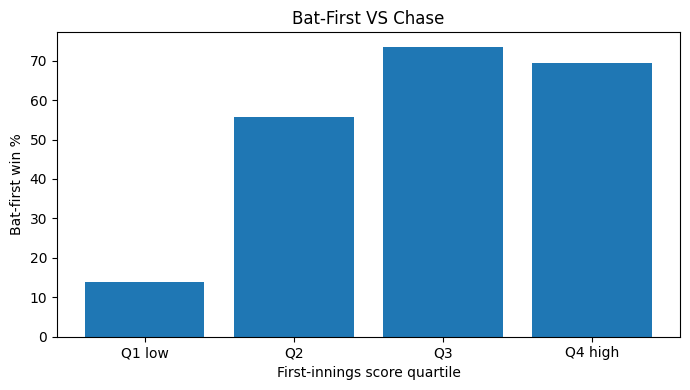

In [22]:
plt.figure(figsize=(7,4))
plt.bar(defend.index.astype(str), defend['bat_first_win_pct'])
plt.ylabel('Bat-first win %')
plt.xlabel('First-innings score quartile')
plt.title('Bat-First VS Chase')
plt.tight_layout()
plt.savefig('adv_defend_by_score.png', dpi=120)
plt.show()

### 11. Run-Rate Momentum

In [24]:
run_rate = df.dropna(subset=['inn1_run_rate','inn2_run_rate']).copy()
run_rate['run_rate_delta'] = run_rate['inn2_run_rate'] - run_rate['inn1_run_rate']
momentum = run_rate.groupby('match_format').agg(
    games=('match_id','count'),
    avg_set_rr=('inn1_run_rate','mean'),
    avg_chase_rr=('inn2_run_rate','mean'),
    avg_rr_delta=('run_rate_delta','mean')).round(2)
print(momentum)

              games  avg_set_rr  avg_chase_rr  \
match_format                                    
ODI              36        4.93          5.29   
T20             107        7.37           6.8   
TEST             57        3.17          3.42   

              avg_rr_delta  
match_format                
ODI                   0.37  
T20                  -0.56  
TEST                  0.25  


### 12. Venue Scoring Profile

In [25]:
venue = (df.dropna(subset=['total_match_runs'])
       .groupby(['venue','city'])
       .agg(matches=('match_id','count'),
            avg_total=('total_match_runs','mean'),
            sd_total=('total_match_runs','std'))
       .query('matches >= 3'))
venue['avg_total'] = venue['avg_total'].round()
venue['sd_total']  = venue['sd_total'].round()
venue['scoring_quartile'] = pd.qcut(venue['avg_total'], 4, labels=[1,2,3,4])
venue = venue.sort_values('avg_total', ascending=False)
venue.head(12)

,,matches,avg_total,sd_total,scoring_quartile
venue,city,,,,
Pallekele International Cricket Stadium,Pallekele,3,571.0,134.0,4
The Wanderers Stadium,Johannesburg,4,555.0,419.0,4
Basin Reserve,Wellington,3,542.0,93.0,4
North Sydney Oval,Sydney,3,450.0,102.0,4
Tribhuvan University International Cricket Ground,Kirtipur,5,405.0,131.0,4
Willowmoore Park,Benoni,4,396.0,81.0,3
Zahur Ahmed Chowdhury Stadium,Chattogram,8,339.0,42.0,3
Dubai International Cricket Stadium,Dubai,8,310.0,42.0,3
Shere Bangla National Stadium,Dhaka,8,306.0,43.0,3
